In [1]:
%load_ext autoreload
%autoreload 2

### Setup

Results taken from [s3://ai2-llm/evaluation/microanneal-peteish-7b-postmortem/](https://us-east-1.console.aws.amazon.com/s3/buckets/ai2-llm?region=us-east-1&bucketType=general&prefix=evaluation/microanneal-peteish-7b-postmortem/&showversions=false).

Results reported in OLMo 2 paper in [Section 4.2.2](https://arxiv.org/pdf/2501.00656#page=23.22), with the final mixture reported in [Table 2](https://arxiv.org/pdf/2501.00656#page=4.96).

For the exact composition of each data mix: See [this Google Sheet](https://docs.google.com/spreadsheets/d/1nE5LsmVaU8yxjOFTFJuqA_pfE14etRLubnJuoRZbITA/edit?gid=829557504#gid=829557504).

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka
from download.hf import pull_predictions_from_hf

In [5]:
# pull_predictions_from_weka("olmo2_microanneals")
pull_predictions_from_hf("allenai/olmo2-microanneals-evals", "olmo2_microanneals")

In [6]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'native_id']
# COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks

df = pd.read_parquet(f'{DATA_DIR}/all_olmo2_microanneals_predictions.parquet', columns=COLS)

# Set the 'mix' column to the value of the 'model' column
df = df.reset_index()
df['mix'] = df['model']
df = df.set_index(['task', 'model', 'step', 'mix'])

print(f'Loaded {len(df):,} instance predictions')

Loaded 125,052 instance predictions


In [7]:
MODELS = df.index.get_level_values('model').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()

In [8]:
# Exclude some models
EXCLUDED_MODELS = [
    'OLMo-medium_peteish7-microanneals_peteish7-weka-microanneal-fromMegaMath1.1-5000_nonmath',
    'OLMo-medium_peteish7-weka-anneal-from-928646-50B-megamath_v1.1.yaml'
]

Computing pairwise comparisons: 100%|██████████| 8/8 [00:00<00:00, 17.99it/s]


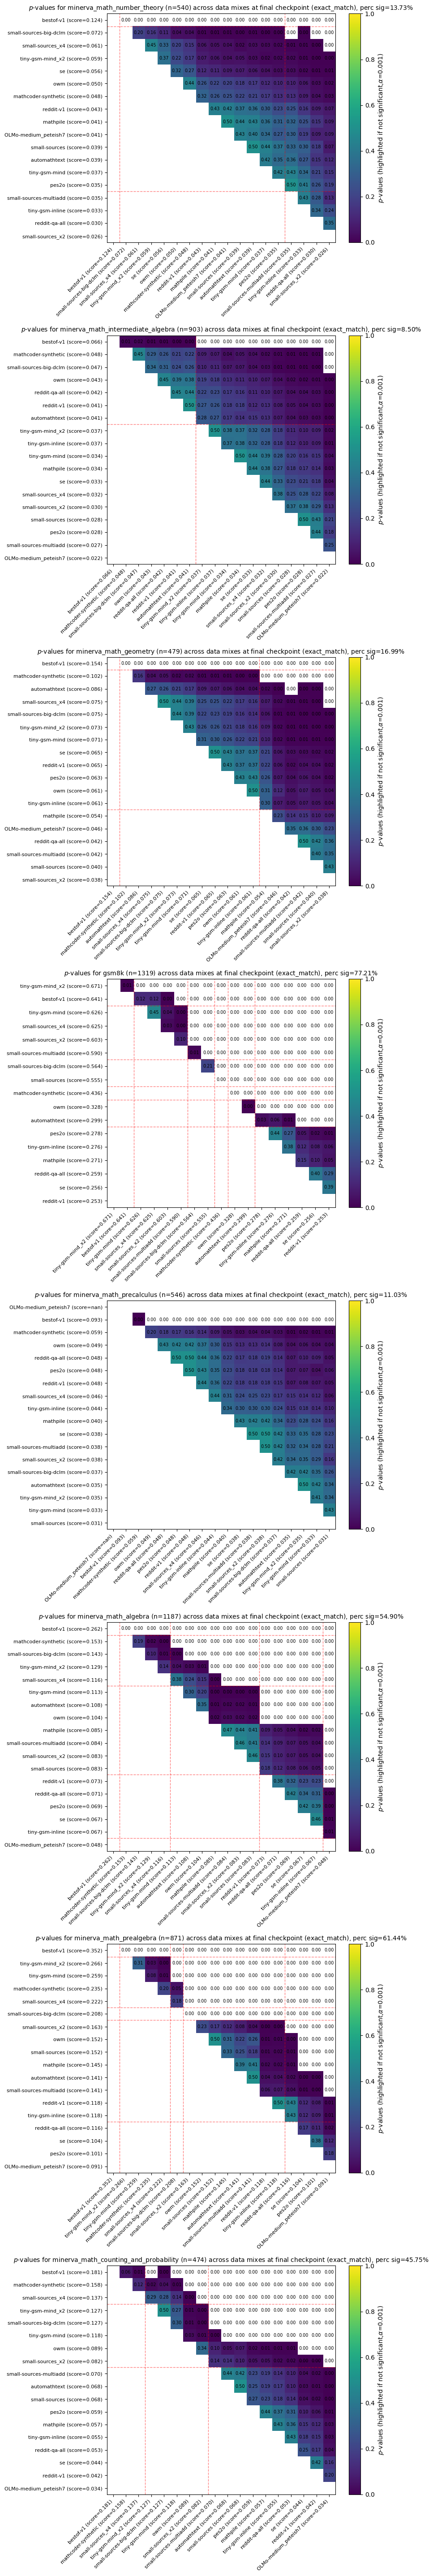

In [14]:
from stats import compute_significance

models = list(set(MODELS) - set(EXCLUDED_MODELS))
tasks  = TASKS

_, p_values, _ = compute_significance(
    df, 
    models=models, 
    metric='exact_match', 
    step=None,     # the models have different checkpoint steps
    last_n=1,      # the "last n" checkpoints to average results
    alpha=0.001,   # significance level
    tasks=tasks, # single tasks (e.g., hellaswag) or suites (e.g., OLMES)
    # tasks=['gsm8k'],
    do_plot=True
)